In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
df = pd.read_csv(r"C:\Users\babus\Data_Spark\Data_analysis_practice\Data Collection\large_multicolumn_outlier_dataset.csv")

In [3]:
df

,Customer_ID,Age,Annual_Income,Monthly_Spend,Savings,Credit_Score,Loan_Amount,Transactions_Per_Month,Avg_Transaction_Value,Account_Tenure_Years,Online_Sessions_Per_Month,Returned_Transactions
0,1,45,75548,1100,6687,807,2603,21,70,2,19,0
1,2,38,53376,2073,5071,672,19182,30,108,16,21,1
2,3,47,38753,1739,18463,629,40953,30,66,9,21,1
3,4,58,75879,1658,13109,654,21312,31,77,8,21,3
4,5,37,53302,2183,13239,780,45783,33,39,13,22,2
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,49,48515,1706,15885,588,22499,19,8,5,14,2
149996,149997,42,44688,966,8726,661,39990,31,70,8,21,0
149997,149998,37,44805,1449,13804,655,21050,27,17,3,20,1
149998,149999,41,38918,1400,14290,600,35213,45,59,5,19,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   Customer_ID                150000 non-null  int64
 1   Age                        150000 non-null  int64
 2   Annual_Income              150000 non-null  int64
 3   Monthly_Spend              150000 non-null  int64
 4   Savings                    150000 non-null  int64
 5   Credit_Score               150000 non-null  int64
 6   Loan_Amount                150000 non-null  int64
 7   Transactions_Per_Month     150000 non-null  int64
 8   Avg_Transaction_Value      150000 non-null  int64
 9   Account_Tenure_Years       150000 non-null  int64
 10  Online_Sessions_Per_Month  150000 non-null  int64
 11  Returned_Transactions      150000 non-null  int64
dtypes: int64(12)
memory usage: 13.7 MB


In [5]:
df.size

1800000

In [6]:
df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Monthly_Spend', 'Savings',
       'Credit_Score', 'Loan_Amount', 'Transactions_Per_Month',
       'Avg_Transaction_Value', 'Account_Tenure_Years',
       'Online_Sessions_Per_Month', 'Returned_Transactions'],
      dtype='object')

In [7]:
df.nunique()

Customer_ID                  150000
Age                              71
Annual_Income                 54863
Monthly_Spend                  3482
Savings                       32290
Credit_Score                    592
Loan_Amount                   46989
Transactions_Per_Month           47
Avg_Transaction_Value           158
Account_Tenure_Years             25
Online_Sessions_Per_Month        39
Returned_Transactions            11
dtype: int64

In [8]:
df['Credit_Score'].unique()

array([807, 672, 629, 654, 780, 734, 727, 634, 385, 728, 804, 671, 745,
       704, 636, 721, 632, 744, 782, 645, 613, 748, 731, 561, 554, 760,
       621, 752, 587, 717, 700, 696, 685, 597, 800, 751, 661, 674, 575,
       710, 691, 573, 659, 584, 813, 695, 708, 735, 756, 665, 687, 589,
       688, 488, 647, 590, 718, 784, 711, 616, 626, 615, 673, 594, 618,
       816, 754, 766, 586, 681, 703, 701, 774, 614, 765, 767, 676, 655,
       725, 656, 667, 736, 770, 670, 668, 720, 628, 741, 842, 608, 633,
       611, 706, 549, 776, 604, 733, 612, 678, 526, 747, 702, 572, 689,
       619, 640, 627, 699, 680, 648, 588, 677, 723, 433, 762, 646, 669,
       642, 657, 639, 650, 707, 638, 643, 705, 777, 622, 742, 607, 545,
       679, 803, 571, 576, 533, 750, 581, 624, 664, 625, 574, 651, 715,
       558, 690, 649, 653, 789, 631, 660, 855, 758, 839, 644, 663, 684,
       652, 563, 641, 779, 512, 560, 712, 675, 637, 743, 775, 662, 716,
       600, 593, 726, 602, 759, 658, 595, 828, 666, 683, 682, 58

In [9]:
df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Monthly_Spend', 'Savings',
       'Credit_Score', 'Loan_Amount', 'Transactions_Per_Month',
       'Avg_Transaction_Value', 'Account_Tenure_Years',
       'Online_Sessions_Per_Month', 'Returned_Transactions'],
      dtype='object')

In [10]:
for col in df.columns:
    print(f"""{col}  :
        mean    | {df[col].mean()}
        median  | {df[col].median()}
        std     | {df[col].std()}               
        var     | {df[col].var()}
        skew    | {df[col].skew()}
        kurtosis| {df[col].kurtosis()}                
        """)           


Customer_ID  :
        mean    | 75000.5
        median  | 75000.5
        std     | 43301.414526548666               
        var     | 1875012500.0
        skew    | 0.0
        kurtosis| -1.2                
        
Age  :
        mean    | 39.69900666666667
        median  | 40.0
        std     | 11.625207266233721               
        var     | 135.14544398289328
        skew    | 0.17911391652350567
        kurtosis| -0.319284640612576                
        
Annual_Income  :
        mean    | 55759.3807
        median  | 55010.0
        std     | 21835.526566715685               
        var     | 476790220.4457464
        skew    | 10.119501470899175
        kurtosis| 209.67285174119394                
        
Monthly_Spend  :
        mean    | 1822.1569933333333
        median  | 1801.0
        std     | 714.7224439092207               
        var     | 510828.17182756914
        skew    | 9.23777372415838
        kurtosis| 186.25500707926668                
        
Sa

In [11]:
status = df.agg(['mean', 'median', 'std', 'var', 'skew', 'kurtosis'])
status

,Customer_ID,Age,Annual_Income,Monthly_Spend,Savings,Credit_Score,Loan_Amount,Transactions_Per_Month,Avg_Transaction_Value,Account_Tenure_Years,Online_Sessions_Per_Month,Returned_Transactions
mean,7.500050e+04,39.699007,5.575938e+04,1822.156993,1.527096e+04,678.804780,2.090135e+04,29.968593,59.506773,6.585427,20.006367,1.500353
median,7.500050e+04,40.000000,5.501000e+04,1801.000000,1.499900e+04,680.000000,2.000500e+04,30.000000,59.000000,6.000000,20.000000,1.000000
std,4.330141e+04,11.625207,2.183553e+04,714.722444,9.311572e+03,71.640845,1.557748e+04,5.461724,24.701497,3.832637,4.479587,1.225815
var,1.875012e+09,135.145444,4.767902e+08,510828.171828,8.670537e+07,5132.410739,2.426578e+08,29.830432,610.163955,14.689107,20.066700,1.502623
skew,0.000000e+00,0.179114,1.011950e+01,9.237774,5.032449e+00,-0.202838,3.454717e+00,0.181698,0.088730,0.242500,0.226211,0.821377
kurtosis,-1.200000e+00,-0.319285,2.096729e+02,186.255007,9.469388e+01,0.719721,5.600025e+01,0.019480,-0.202551,-0.333240,0.034532,0.699258


# BOXPLOT

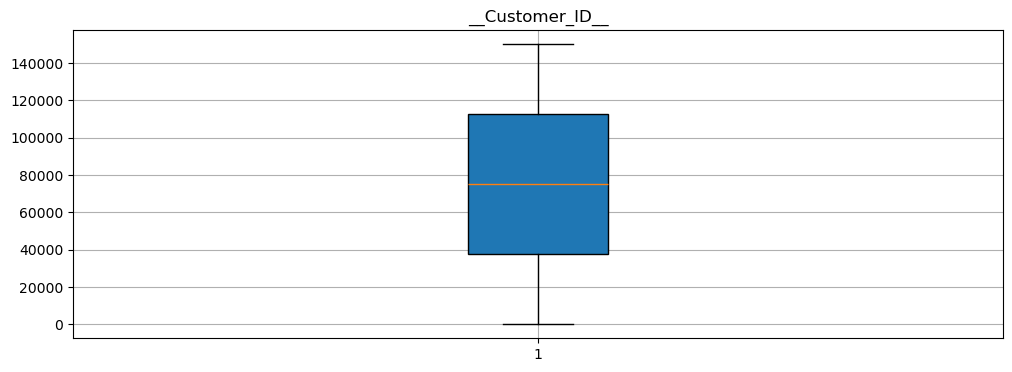

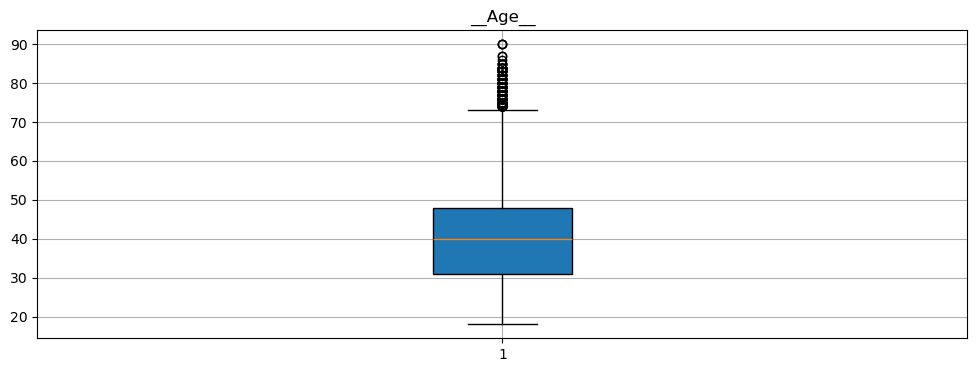

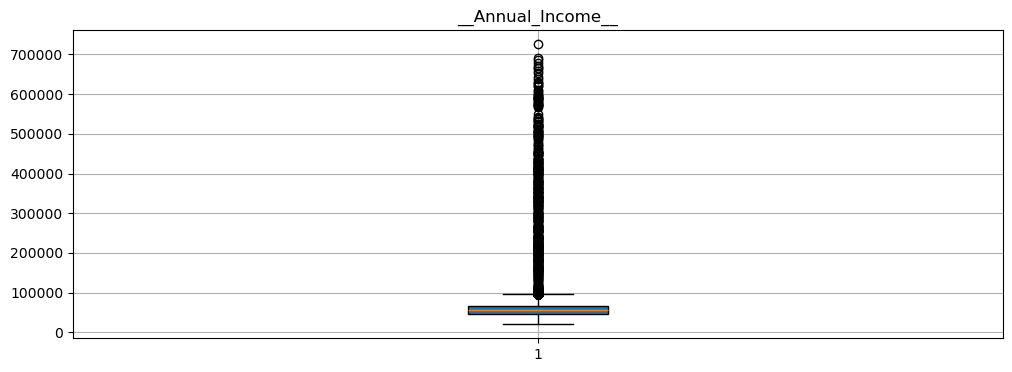

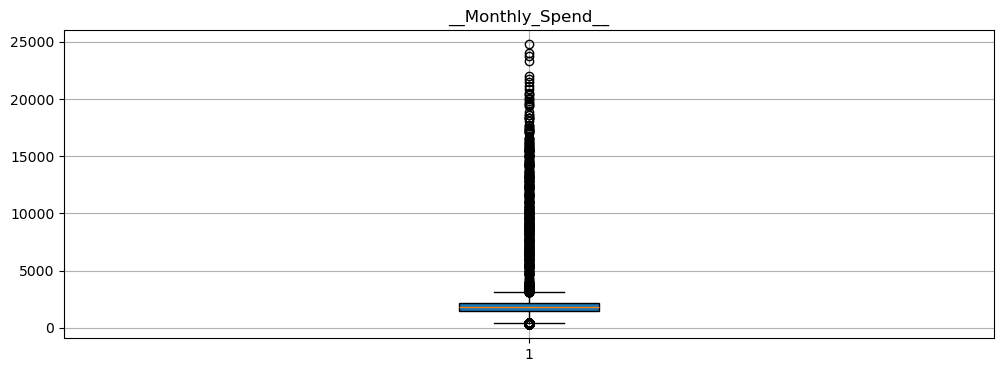

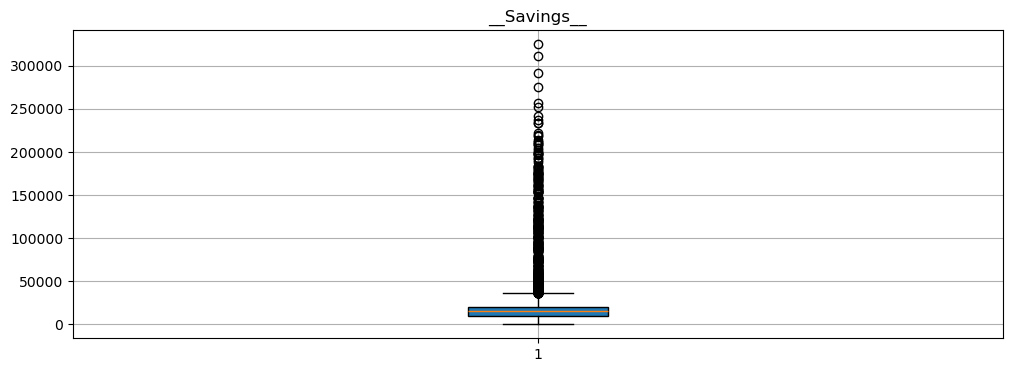

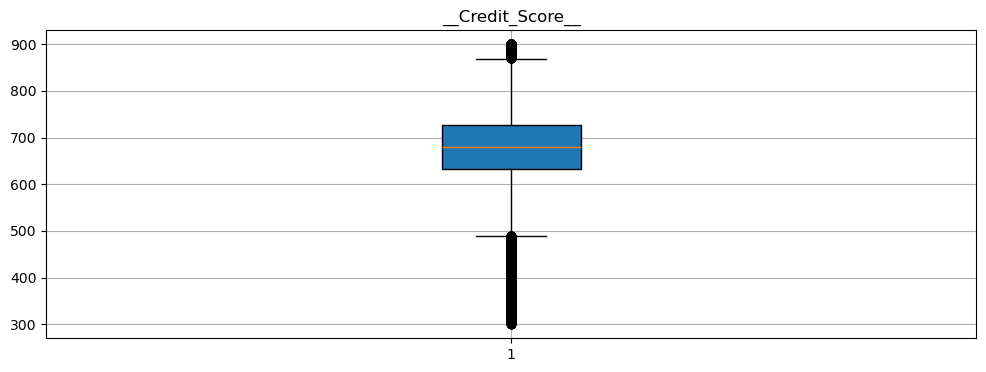

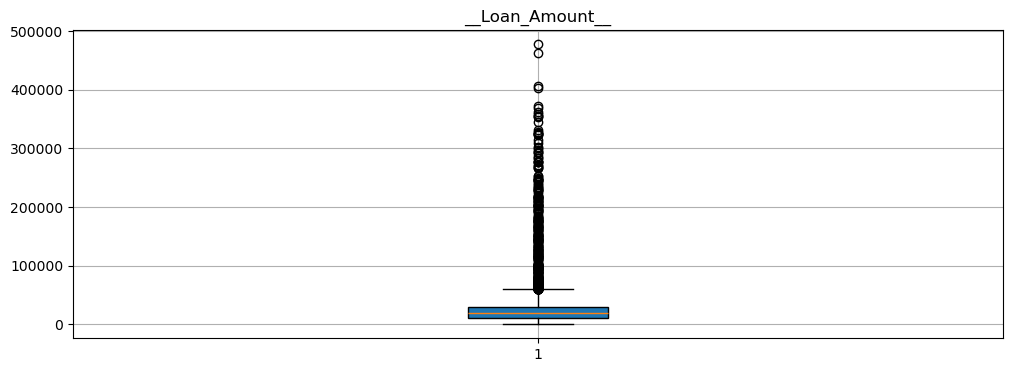

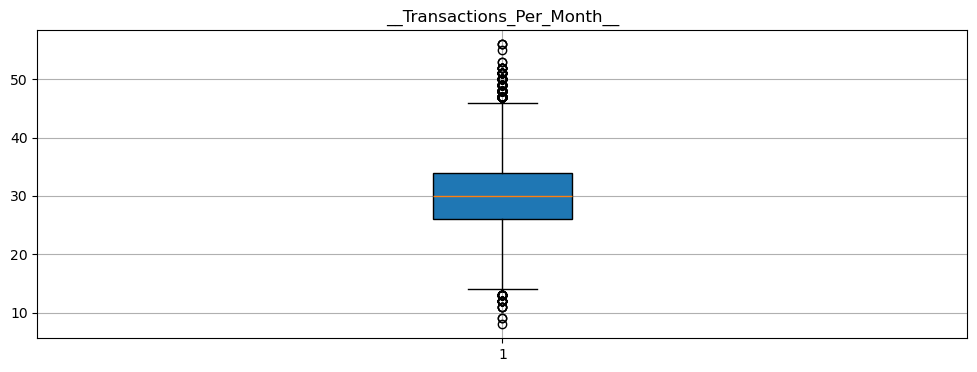

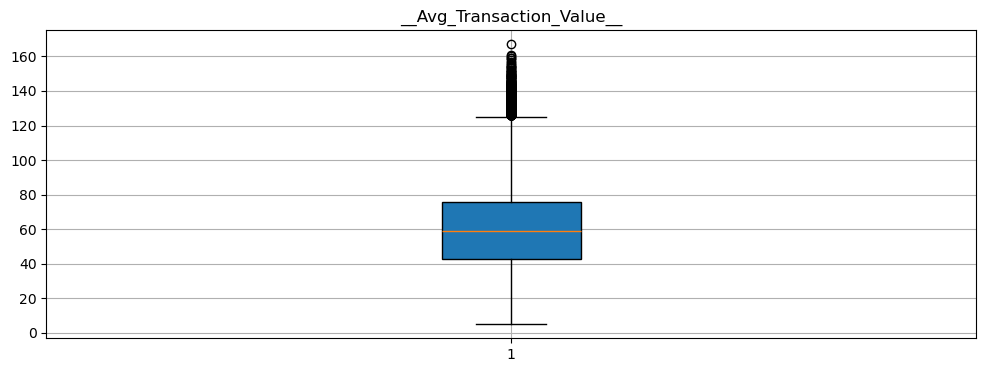

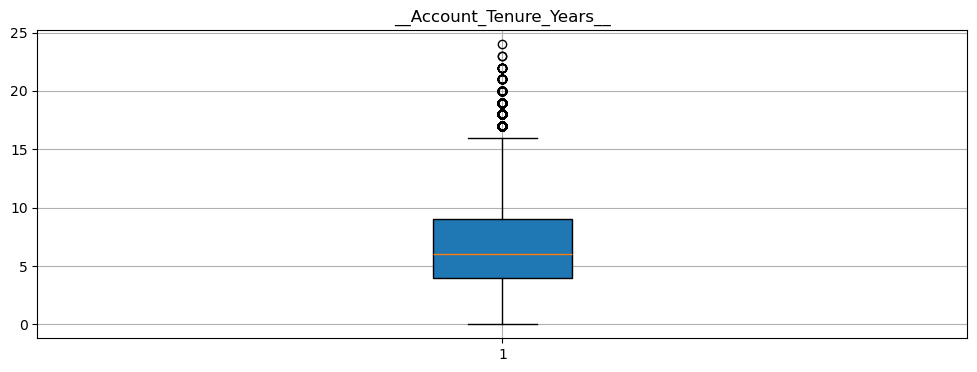

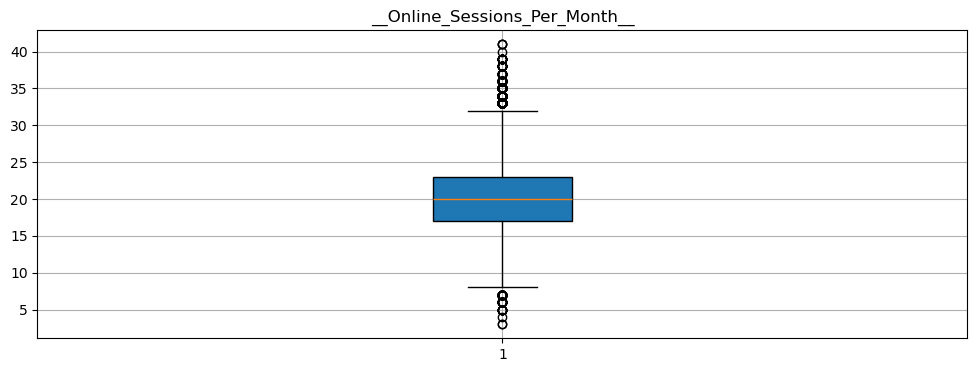

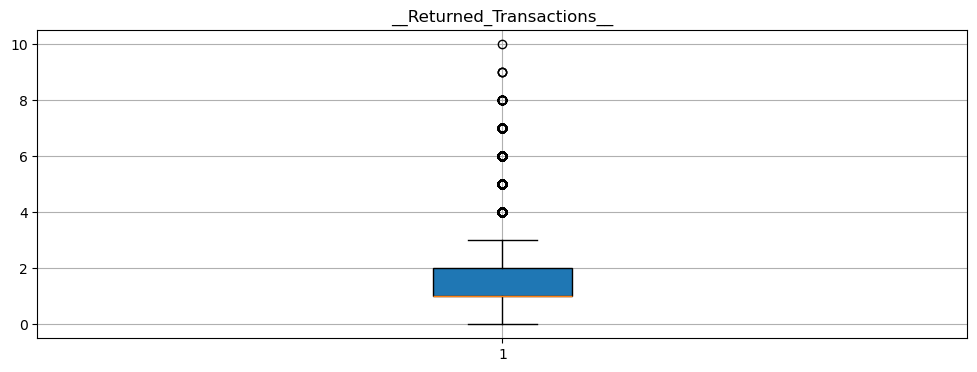

In [12]:
for col in df.columns:
    plt.figure(figsize=(12,4))
    plt.boxplot(df[col],patch_artist=True)
    plt.title(f"__{col}__")
    plt.grid()
    plt.show()

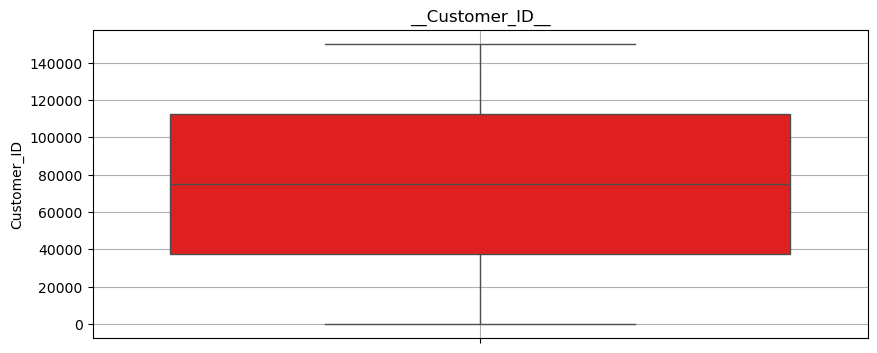

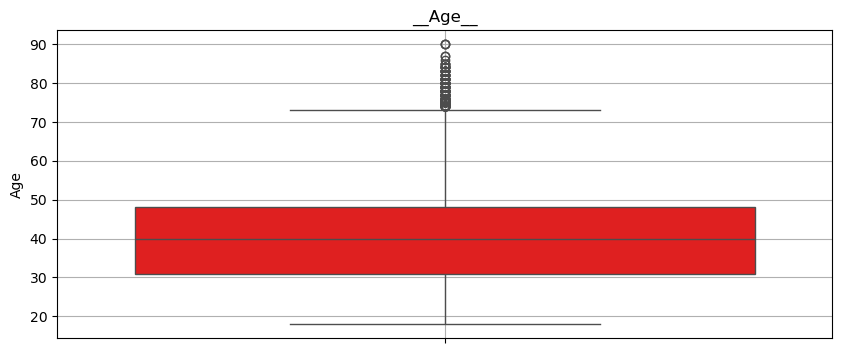

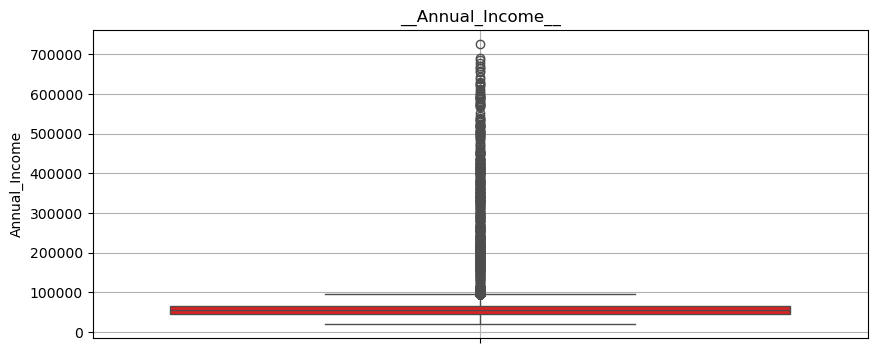

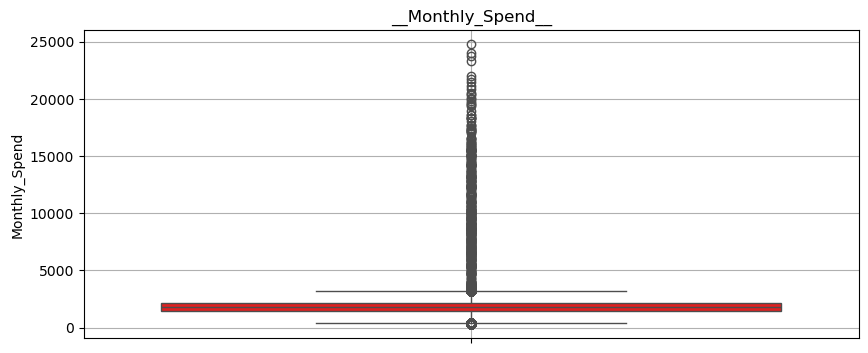

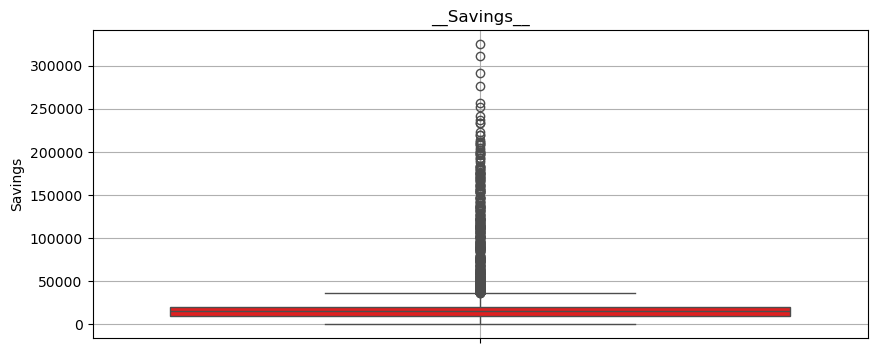

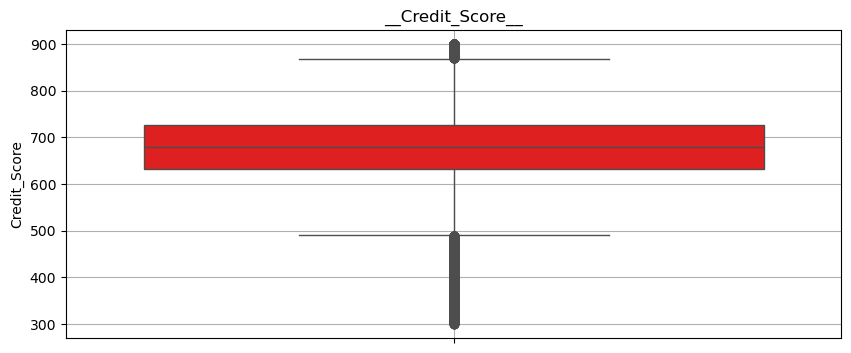

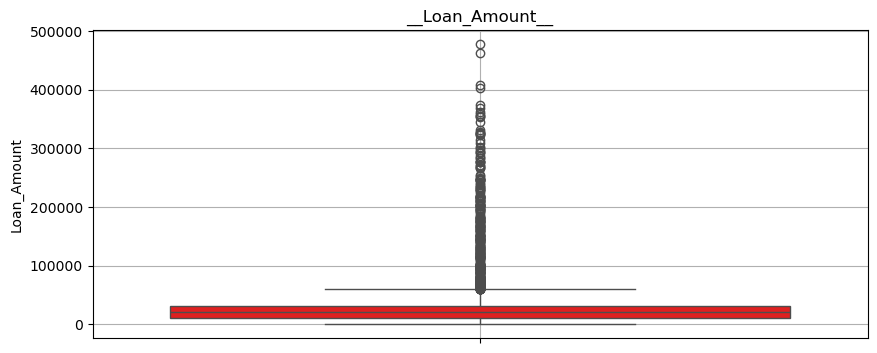

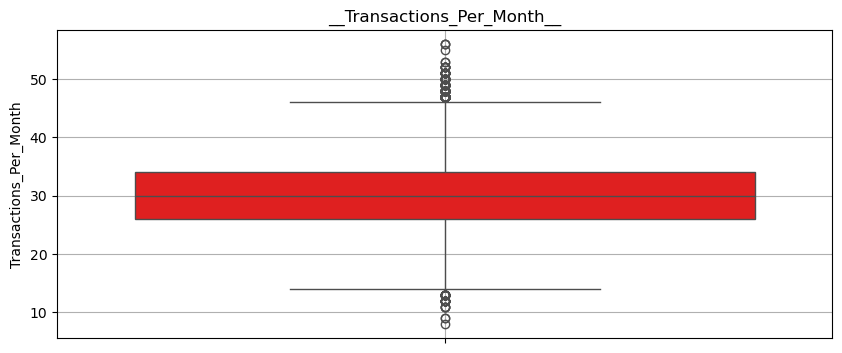

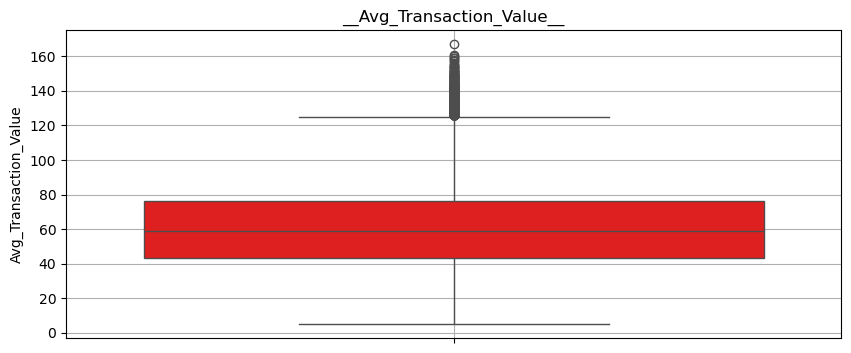

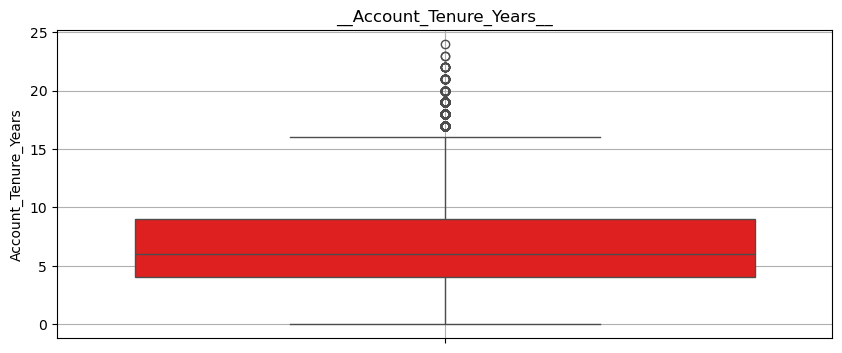

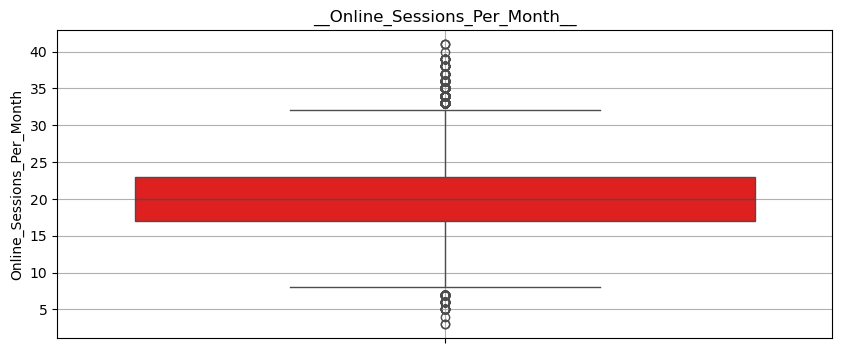

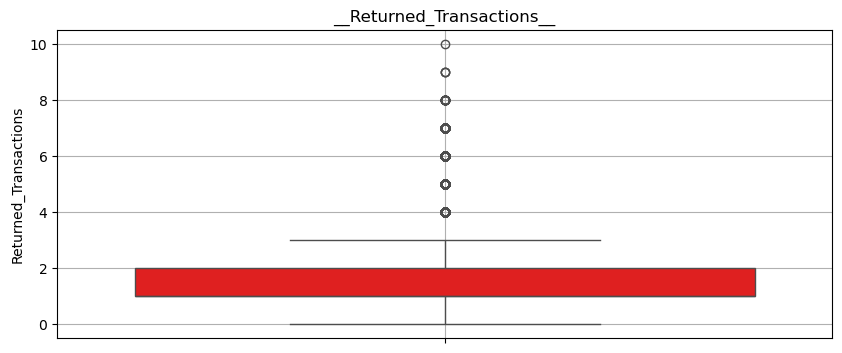

In [13]:
for col in df.columns:
    plt.figure(figsize=(10,4))
    sns.boxplot(df[col],color='r')
    plt.grid()
    plt.title(f"__{col}__")
    plt.show()

In [14]:
df.count()

Customer_ID                  150000
Age                          150000
Annual_Income                150000
Monthly_Spend                150000
Savings                      150000
Credit_Score                 150000
Loan_Amount                  150000
Transactions_Per_Month       150000
Avg_Transaction_Value        150000
Account_Tenure_Years         150000
Online_Sessions_Per_Month    150000
Returned_Transactions        150000
dtype: int64

In [15]:
len(df.columns)

12

In [16]:
df.shape

(150000, 12)

# SUBPLOT

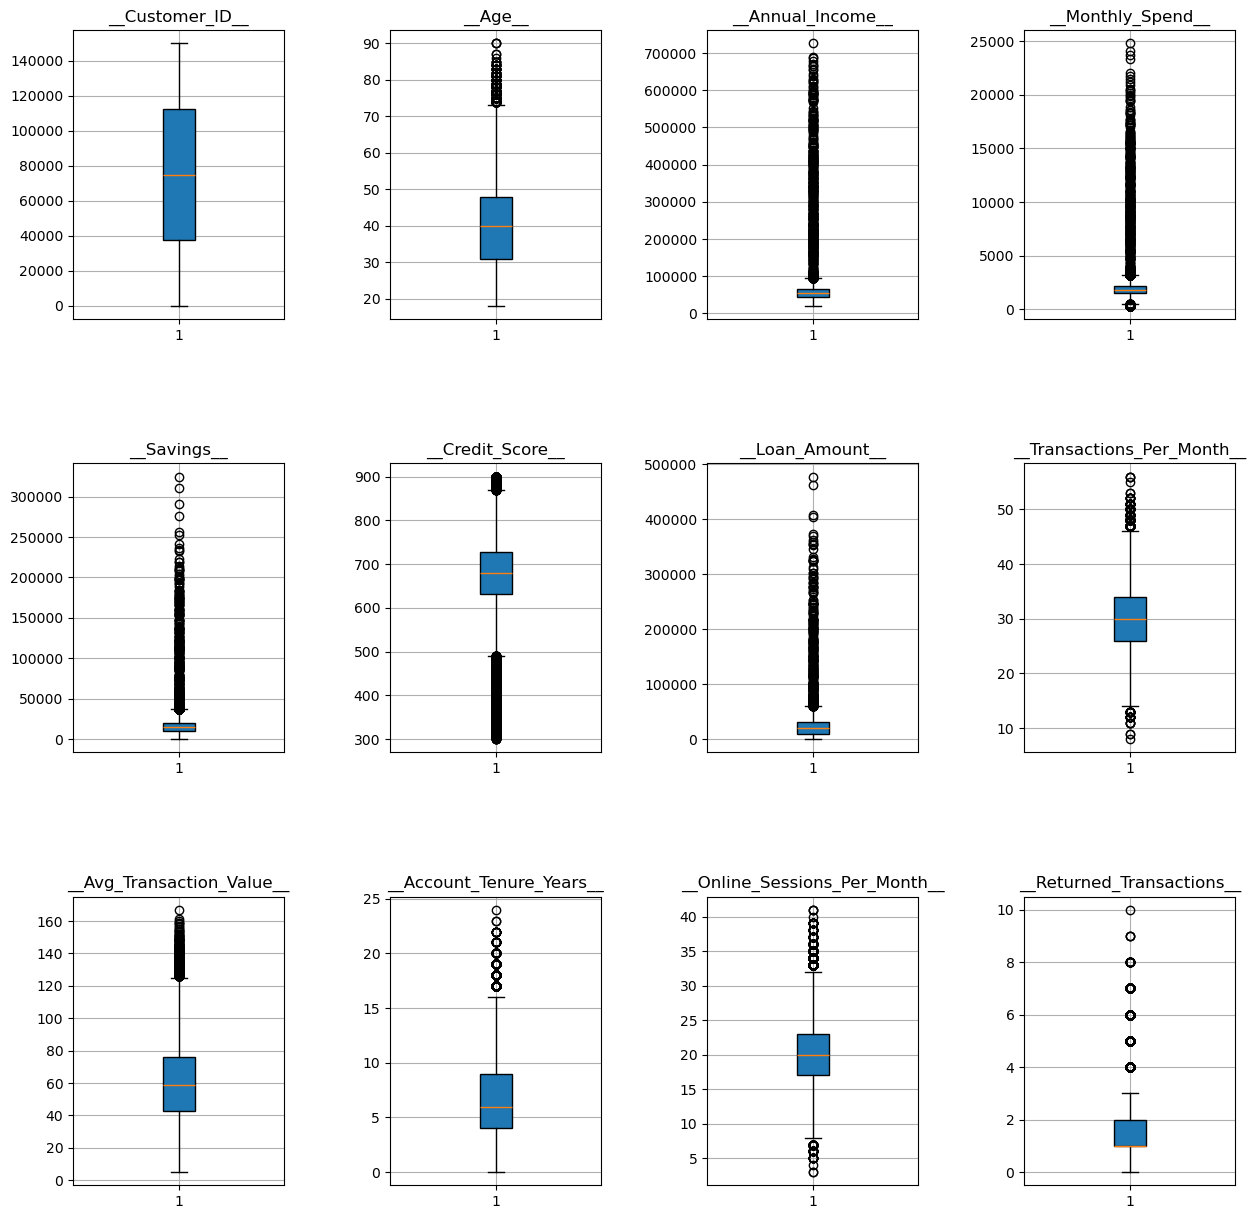

In [17]:

plt.figure(figsize=(15,15))   
for i,col in enumerate(df.columns,start=1):
    plt.subplot(3,4,i)
    plt.boxplot(df[col],patch_artist=True)
    plt.title(f"__{col}__")
    plt.grid()
plt.subplots_adjust(wspace=0.5,hspace=0.5)
plt.show()

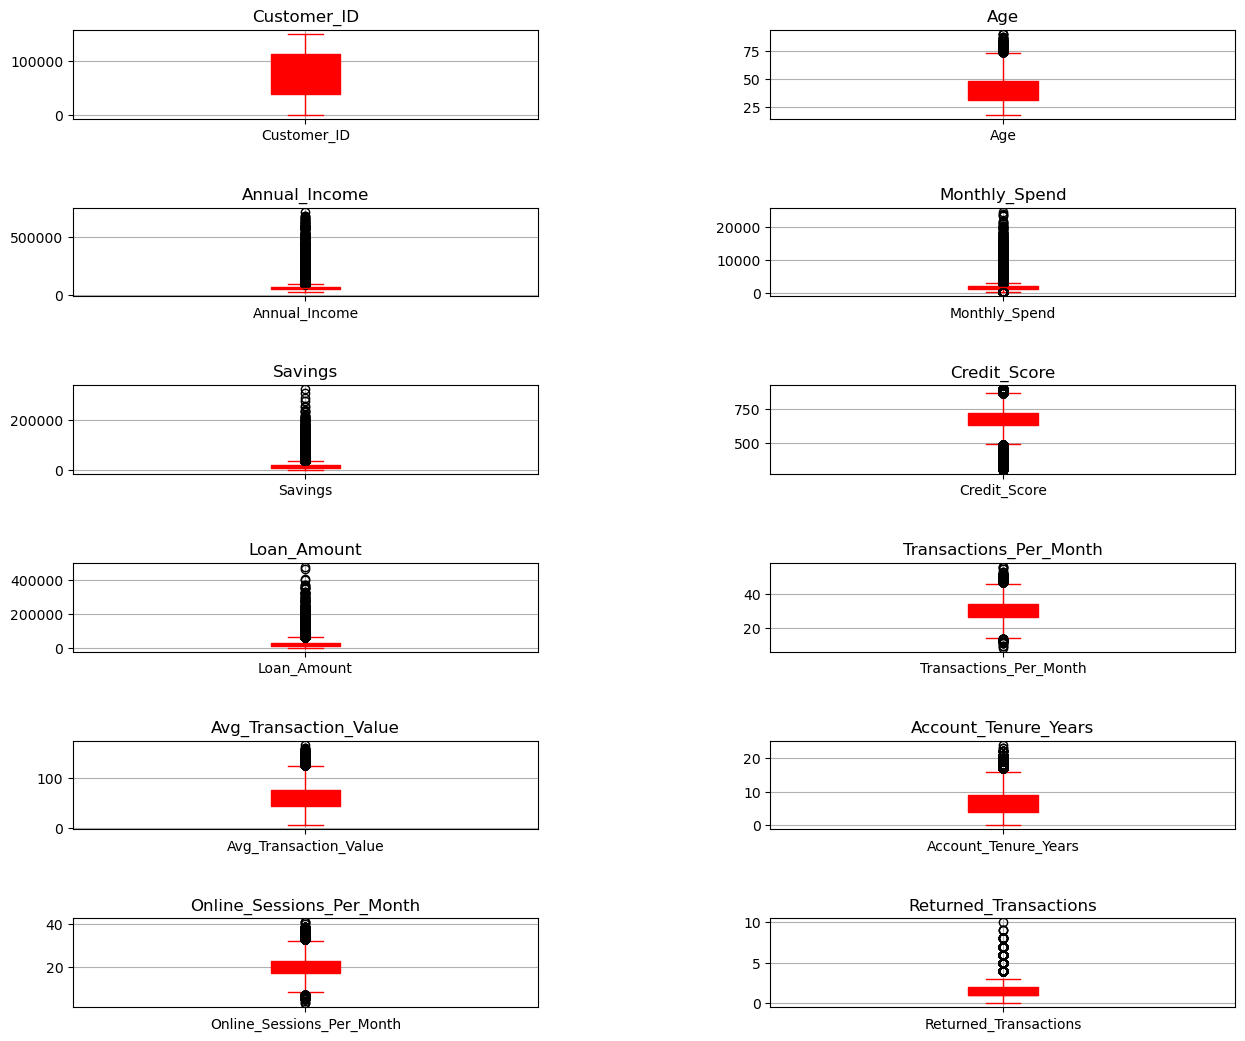

In [18]:

df.plot(kind='box', subplots=True,color='r', layout=(7, 2), figsize=(15, 15),grid=True, title=list(df.columns),patch_artist=True)
plt.subplots_adjust(wspace=0.5,hspace=1)

In [19]:
# for col in df.columns:
#     plt.scatter(x=df['Customer_ID'],y=df[col])
#     plt.title(f"__{col}__")
#     plt.show()